In [ ]:
!git clone https://github.com/HenryNVP/fastvit-pet-mobile.git
%cd fastvit-pet-mobile

Cloning into 'fastvit-pet-mobile'...
remote: Enumerating objects: 234, done.
remote: Counting objects: 100% (234/234), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 234 (delta 73), reused 171 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (234/234), 3.59 MiB | 50.42 MiB/s, done.
Resolving deltas: 100% (73/73), done.
/content/fastvit-pet-mobile


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.0 MB/s eta 0:00:00


In [ ]:
!pip install performer-pytorch

In [ ]:
!cat requirements.txt

torch
torchvision
torchaudio

timm
numpy
scipy
matplotlib
Pillow
PyYAML
onnxruntime


In [ ]:
import pkg_resources

packages = [
    "torch",
    "torchvision",
    "torchaudio",
    "timm",
    "numpy",
    "scipy",
    "matplotlib",
    "Pillow",
    "PyYAML",
    "onnxruntime",
    "performer-pytorch"
]

for pkg in packages:
    try:
        ver = pkg_resources.get_distribution(pkg).version
        print(f"{pkg:12} -> {ver}")
    except pkg_resources.DistributionNotFound:
        print(f"{pkg:12} -> NOT INSTALLED")


torch        -> 2.9.0+cu126
torchvision  -> 0.24.0+cu126
torchaudio   -> 2.9.0+cu126
timm         -> 1.0.22
numpy        -> 2.0.2
scipy        -> 1.16.3
matplotlib   -> 3.10.0
Pillow       -> 11.3.0
PyYAML       -> 6.0.3
onnxruntime  -> 1.23.2
performer-pytorch -> 1.1.4


/tmp/ipython-input-2840708291.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [ ]:
!python scripts/get_data.py
!python scripts/split_dataset.py

/content/fastvit-pet-mobile/scripts/get_data.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(destination)
Prepared train=3680 val=1832 test=1837


In [ ]:
# Download and load checkpoint
!wget -O fastvit_t8_p.pth.tar \
"https://docs-assets.developer.apple.com/ml-research/models/fastvit/image_classification_models/fastvit_t8.pth.tar"

--2025-12-15 23:16:49--  https://docs-assets.developer.apple.com/ml-research/models/fastvit/image_classification_models/fastvit_t8.pth.tar
Resolving docs-assets.developer.apple.com (docs-assets.developer.apple.com)... 17.253.118.202, 2403:300:a30:f100::2, 2403:300:a30:f000::1
Connecting to docs-assets.developer.apple.com (docs-assets.developer.apple.com)|17.253.118.202|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16378213 (16M) [application/x-tar]
Saving to: ‘fastvit_t8_p.pth.tar’

fastvit_t8_p.pth.ta 100%[===================>]  15.62M  71.2MB/s    in 0.2s    

2025-12-15 23:16:50 (71.2 MB/s) - ‘fastvit_t8_p.pth.tar’ saved [16378213/16378213]



changed from fastvit_t8 to fastvit_t8_P

In [ ]:
!python fastvit/train.py data \
    --model fastvit_t8_P \
    --resume fastvit_t8_p.pth.tar \
    --finetune \
    --freeze-stages 0 1 2 3 \
    --num-classes 37 \
    -b 192 --lr 1e-3 \
    --epochs 20 \
    --output ./output \
    --input-size 3 256 256

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
/content/fastvit-pet-mobile/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit-pet-mo

In [ ]:
!ls /content/fastvit-pet-mobile/output


20251201-154310-fastvit_t8_P-256  20251201-155233-fastvit_t8_P-256
20251201-154802-fastvit_t8_P-256


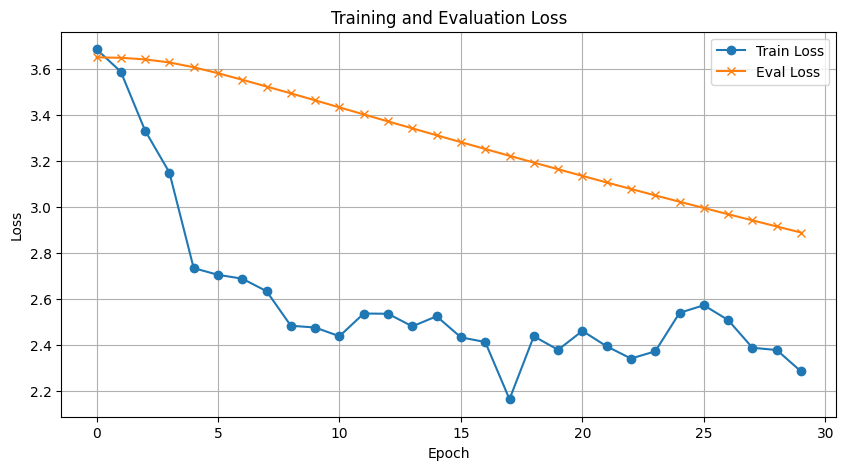

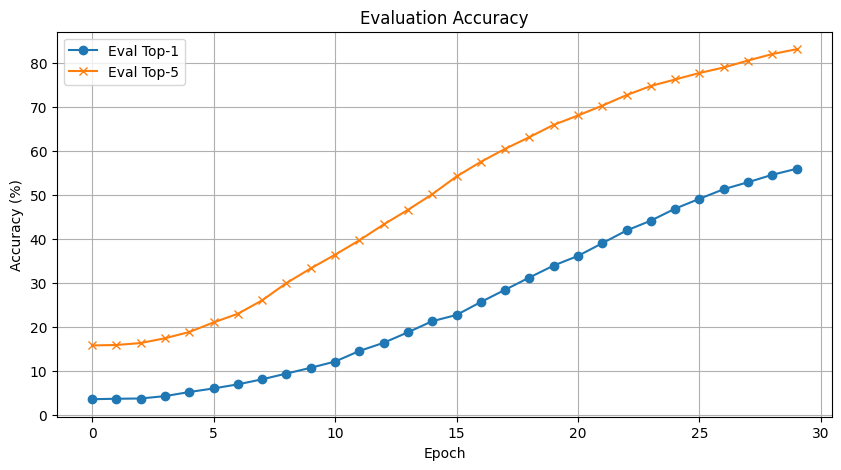

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

summary_path = "/content/fastvit-pet-mobile/fastvit-pet-mobile/output20251201-160418-fastvit_t8_P-256/summary.csv"
df = pd.read_csv(summary_path)
df.head()


# Plot training and evaluation loss
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
plt.plot(df['epoch'], df['eval_loss'], label='Eval Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot evaluation Top-1 and Top-5 accuracy
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['eval_top1'], label='Eval Top-1', marker='o')
plt.plot(df['epoch'], df['eval_top5'], label='Eval Top-5', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Evaluation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Download and load checkpoint
!wget -O fastvit_sa12_p.pth.tar \
"https://docs-assets.developer.apple.com/ml-research/models/fastvit/image_classification_models/fastvit_sa12.pth.tar"

--2025-12-15 23:16:50--  https://docs-assets.developer.apple.com/ml-research/models/fastvit/image_classification_models/fastvit_sa12.pth.tar
Resolving docs-assets.developer.apple.com (docs-assets.developer.apple.com)... 17.253.118.202, 2403:300:a30:f100::2, 2403:300:a30:f000::1
Connecting to docs-assets.developer.apple.com (docs-assets.developer.apple.com)|17.253.118.202|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46644177 (44M) [application/x-tar]
Saving to: ‘fastvit_sa12_p.pth.tar’

fastvit_sa12_p.pth. 100%[===================>]  44.48M   124MB/s    in 0.4s    

2025-12-15 23:16:51 (124 MB/s) - ‘fastvit_sa12_p.pth.tar’ saved [46644177/46644177]



In [ ]:
!python fastvit/train.py data \
    --model fastvit_sa12_P \
    --resume fastvit_sa12_p.pth.tar \
    --finetune \
    --freeze-stages 0 1 2  \
    --num-classes 37 \
    -b 192 --lr 1e-3 \
    --epochs 50 \
    --output ./output \
    --input-size 3 256 256

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:978: Us

In [ ]:
!ls ./output/20251215-231705-fastvit_sa12_P-256/checkpoint-59.pth.tar

./output/20251215-231705-fastvit_sa12_P-256/checkpoint-59.pth.tar


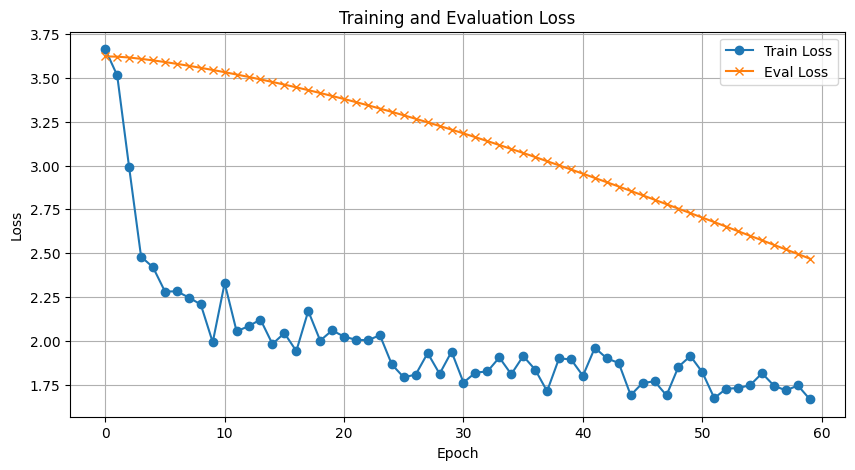

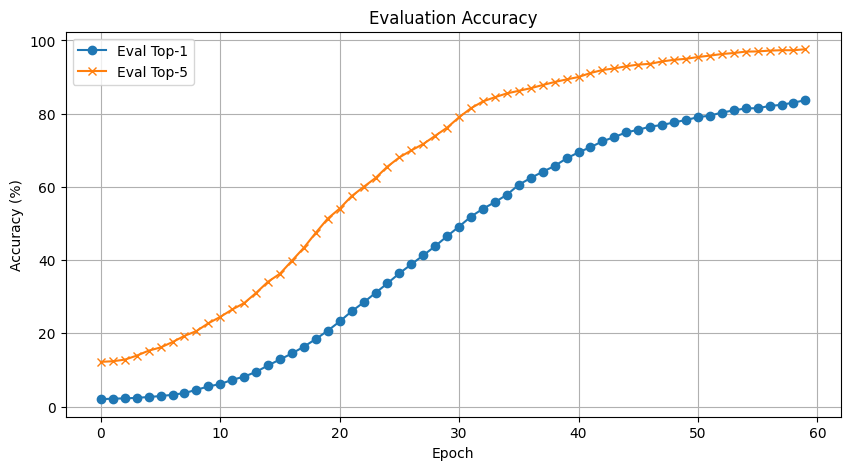

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
summary_path = "./output/20251215-231705-fastvit_sa12_P-256/summary.csv"
df = pd.read_csv(summary_path)
df.head()


# Plot training and evaluation loss
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
plt.plot(df['epoch'], df['eval_loss'], label='Eval Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot evaluation Top-1 and Top-5 accuracy
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['eval_top1'], label='Eval Top-1', marker='o')
plt.plot(df['epoch'], df['eval_top5'], label='Eval Top-5', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Evaluation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from timm.models import create_model, load_checkpoint
import fastvit.models as models
from fastvit.models.modules.mobileone import reparameterize_model

tuned_teacher = create_model(
    "fastvit_sa12_P",
    pretrained=False,
    num_classes=37,
)

load_checkpoint(tuned_teacher, "./output/20251215-231705-fastvit_sa12_P-256/model_best.pth.tar", use_ema=False)

tuned_teacher.eval()
tuned_teacher = reparameterize_model(tuned_teacher)
tuned_teacher = tuned_teacher.cuda()

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:978: UserWarning: Overwriting fastvit_t12 in registry with fastvit.models.fastvit.fastvit_t12. This is because the name bein

If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first


Detected classes: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
Number of classes: 37

Prediction: Maine_Coon (index 6)
Confidence: 0.7914


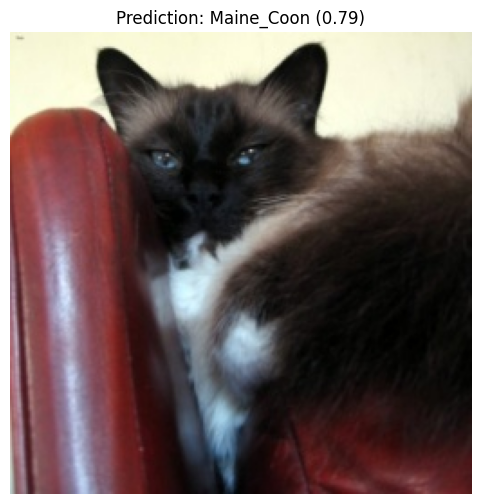

In [ ]:
import os
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# -----------------------------------------------------
# 1. Automatically load class names from training folder
# -----------------------------------------------------
train_data_path = "/content/fastvit-pet-mobile/data/train"

class_names = sorted([
    d for d in os.listdir(train_data_path)
    if os.path.isdir(os.path.join(train_data_path, d))
])

print("Detected classes:", class_names)
print("Number of classes:", len(class_names))

# -----------------------------------------------------
# 2. Load and preprocess the test image
# -----------------------------------------------------
img_path = "/content/fastvit-pet-mobile/data/test/Birman/Birman_75.jpg"
img = Image.open(img_path).convert("RGB")

preprocess = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

input_tensor = preprocess(img).unsqueeze(0).to("cuda")

# -----------------------------------------------------
# 3. Run model inference
# -----------------------------------------------------
tuned_teacher.eval()
with torch.no_grad():
    logits = tuned_teacher(input_tensor)
    probs = torch.softmax(logits, dim=1)[0]

pred_idx = torch.argmax(probs).item()
pred_class = class_names[pred_idx]
pred_conf = probs[pred_idx].item()

print(f"\nPrediction: {pred_class} (index {pred_idx})")
print(f"Confidence: {pred_conf:.4f}")

# -----------------------------------------------------
# 4. Show image + prediction
# -----------------------------------------------------
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {pred_class} ({pred_conf:.2f})")
plt.show()


In [ ]:
!python fastvit/validate.py data \
    --model fastvit_sa12_P \
    --checkpoint ./output/20251215-231705-fastvit_sa12_P-256/model_best.pth.tar \
    --num-classes 37 \
    --batch-size 128 \
    --input-size 3 256 256 \
    --split test \
    --use-ema \
    --native-amp

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:978: Us

In [ ]:
!pip install onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.0/683.0 kB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 14.6 MB/s eta 0:00:00


In [ ]:
!python scripts/export_models.py \
    --checkpoint ./output/20251215-231705-fastvit_sa12_P-256/model_best.pth.tar \
    --model fastvit_sa12_P \
    --num-classes 37 \
    --input-size 256 \
    --reparameterize \
    --subdir teacher

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:978: Us

In [ ]:
!python scripts/benchmark_models.py \
    --checkpoint ./output/20251215-231705-fastvit_sa12_P-256/model_best.pth.tar \
    --model fastvit_sa12_P \
    --num-classes 37 \
    --input-size 256 \
    --reparameterize \
    --subdir teacher

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:978: Us

In [ ]:
!find ./output/20251215-231705-fastvit_sa12_P-256/model_best.pth.tar

./output/20251215-231705-fastvit_sa12_P-256/model_best.pth.tar


In [ ]:
import torch

ckpt_path = "./output/20251215-231705-fastvit_sa12_P-256/model_best.pth.tar"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# Many timm-style checkpoints store weights under 'state_dict'
state_dict = ckpt.get("state_dict", ckpt)

torch.save(state_dict, "./output/teacher_weights_only.pth")
print("Saved weights-only checkpoint to ./output/teacher_weights_only.pth")


Saved weights-only checkpoint to ./output/teacher_weights_only.pth


In [ ]:
!python fastvit/train.py data \
  --model fastvit_sa12_P \
  --initial-checkpoint ./output/teacher_weights_only.pth \
  --finetune \
  --num-classes 37 \
  -b 192 \
  --lr 3e-4 \
  --epochs 20 \
  --output ./student_output_resume \
  --input-size 3 256 256 \
  --teacher-model fastvit_sa12_P \
  --teacher-path ./output/20251215-231705-fastvit_sa12_P-256/model_best.pth.tar \
  --distillation-type hard


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:978: Us

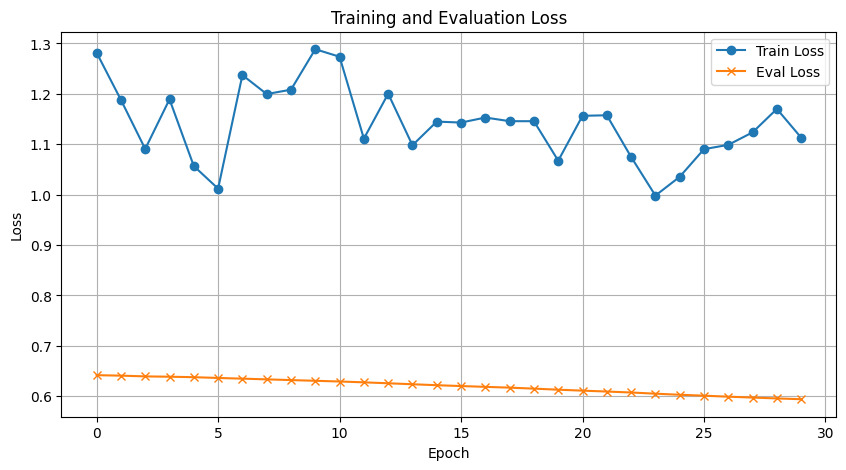

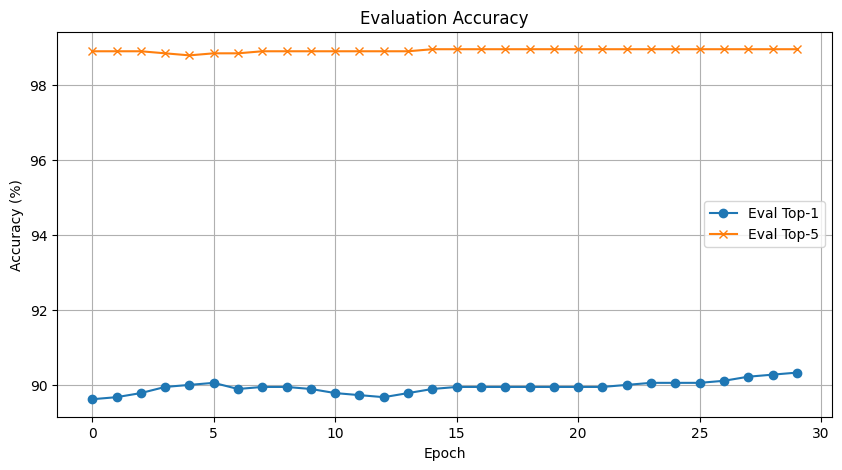

In [ ]:
summary_path = "./student_output_resume/20251215-234148-fastvit_sa12_P-256/summary.csv"
df = pd.read_csv(summary_path)
df.head()


# Plot training and evaluation loss
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
plt.plot(df['epoch'], df['eval_loss'], label='Eval Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot evaluation Top-1 and Top-5 accuracy
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['eval_top1'], label='Eval Top-1', marker='o')
plt.plot(df['epoch'], df['eval_top5'], label='Eval Top-5', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Evaluation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from timm.models import create_model, load_checkpoint
import fastvit.models as models
from fastvit.models.modules.mobileone import reparameterize_model

tuned_teacher = create_model(
    "fastvit_sa12_P",
    pretrained=False,
    num_classes=37,
)

load_checkpoint(tuned_teacher, "./student_output_resume/20251215-234148-fastvit_sa12_P-256/model_best.pth.tar", use_ema=False)

tuned_teacher.eval()
tuned_teacher = reparameterize_model(tuned_teacher)
tuned_teacher = tuned_teacher.cuda()

Detected classes: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
Number of classes: 37

Prediction: Maine_Coon (index 6)
Confidence: 0.8902


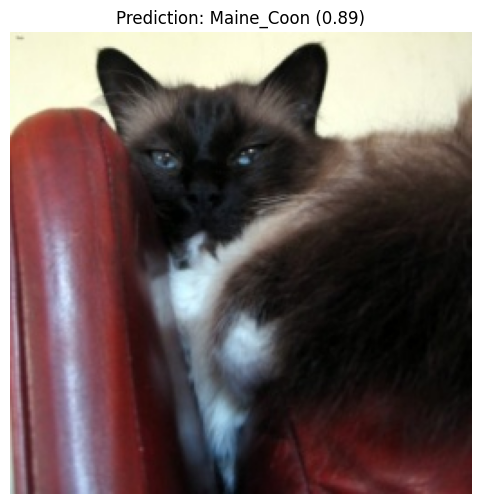

In [ ]:
import os
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# -----------------------------------------------------
# 1. Automatically load class names from training folder
# -----------------------------------------------------
train_data_path = "/content/fastvit-pet-mobile/data/train"

class_names = sorted([
    d for d in os.listdir(train_data_path)
    if os.path.isdir(os.path.join(train_data_path, d))
])

print("Detected classes:", class_names)
print("Number of classes:", len(class_names))

# -----------------------------------------------------
# 2. Load and preprocess the test image
# -----------------------------------------------------
img_path = "/content/fastvit-pet-mobile/data/test/Birman/Birman_75.jpg"
img = Image.open(img_path).convert("RGB")

preprocess = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

input_tensor = preprocess(img).unsqueeze(0).to("cuda")

# -----------------------------------------------------
# 3. Run model inference
# -----------------------------------------------------
tuned_teacher.eval()
with torch.no_grad():
    logits = tuned_teacher(input_tensor)
    probs = torch.softmax(logits, dim=1)[0]

pred_idx = torch.argmax(probs).item()
pred_class = class_names[pred_idx]
pred_conf = probs[pred_idx].item()

print(f"\nPrediction: {pred_class} (index {pred_idx})")
print(f"Confidence: {pred_conf:.4f}")

# -----------------------------------------------------
# 4. Show image + prediction
# -----------------------------------------------------
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {pred_class} ({pred_conf:.2f})")
plt.show()

In [ ]:
!python scripts/export_models.py \
    --checkpoint ./student_output_resume/20251215-234148-fastvit_sa12_P-256/model_best.pth.tar \
    --model fastvit_sa12_P \
    --num-classes 37 \
    --input-size 256 \
    --subdir student \
    --reparameterize

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:978: Us

In [ ]:
!ls ./exports/student/

model.onnx  model.onnx.data  model_scripted.pt


In [ ]:
!python scripts/benchmark_models.py \
    --checkpoint ./student_output_resume/20251215-234148-fastvit_sa12_P-256/model_best.pth.tar  \
    --model fastvit_sa12_P \
    --num-classes 37 \
    --input-size 256 \
    --reparameterize \
    --subdir teacher

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
If for semantic segmentation, please install mmsegmentation first
If for detection, please install mmdetection first
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:956: UserWarning: Overwriting fastvit_t8 in registry with fastvit.models.fastvit.fastvit_t8. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/fastvit-pet-mobile/fastvit/models/fastvit.py:978: Us

In [ ]:
import torch
import torch.ao.quantization as tq
from timm.models import create_model, load_checkpoint
from fastvit.models.modules.mobileone import reparameterize_model
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ----- CONFIG (adjust these) -----
CKPT = "./student_output/20251202-072456-fastvit_sa12_P-256/model_best.pth.tar"  # student checkpoint
MODEL_NAME = "fastvit_sa12_P"     # student model name
NUM_CLASSES = 37
CALIB_DIR = "data/validation"          # or "train" - folder with class subdirs
BATCH_SIZE = 32
NUM_CALIB_BATCHES = 20
BACKEND = "fbgemm"                # "qnnpack" for ARM/mobile
OUT_TS_INT8 = "./exports/student/model_int8_scripted.pt"
# ---------------------------------

# 1. Build FP32 model and load weights
model = create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
load_checkpoint(model, CKPT, use_ema=False)
model.eval()
model.cpu()

# 2. Attach quantization config
torch.backends.quantized.engine = BACKEND
model.qconfig = tq.get_default_qconfig(BACKEND)

# 3. Prepare model (insert observers)
tq.prepare(model, inplace=True)

# 4. Calibration
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

calib_dataset = datasets.ImageFolder(CALIB_DIR, transform=transform)
calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, shuffle=False)

with torch.inference_mode():
    for i, (x, _) in enumerate(calib_loader):
        model(x)
        if i + 1 >= NUM_CALIB_BATCHES:
            break

# 5. Convert to INT8
tq.convert(model, inplace=True)

# 6. TRACE (not script) and save INT8 TorchScript
traced_int8 = torch.jit.trace(model)
traced_int8.save(OUT_TS_INT8)
print("Saved INT8 TorchScript student model to:", OUT_TS_INT8)


/tmp/ipython-input-1277523824.py:30: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  tq.prepare(model, inplace=True)
/tmp/ipython-input-1277523824.py:50: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please m

RuntimeError: example_kwarg_inputs should be a dict

In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType
CKPT = "./student_output/20251202-072456-fastvit_sa12_P-256/model_best.pth.tar"  # student ckpt
OUT_ONNX = "./exports/student/model_fp32_clean.onnx"

model = create_model("fastvit_sa12_P", pretrained=False, num_classes=37)
load_checkpoint(model, CKPT, use_ema=False)
model.eval().cpu()

#model = reparameterize_model(model)   # optional but good for FastViT deploy
model.eval()
model.cpu()

print("Exporting clean FP32 ONNX...")
dummy = torch.randn(1, 3, 256, 256)

torch.onnx.export(
    model,
    dummy,
    "model_new.onnx",
    input_names=["input"],
    output_names=["logits"],
    opset_version=17,
    do_constant_folding=True,
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
)

quantize_dynamic("model_new.onnx", "model_new_int8.onnx", weight_type=QuantType.QInt8)

/tmp/ipython-input-951912521.py:16: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1202 08:49:26.472000 196 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


Exporting clean FP32 ONNX...
[torch.onnx] Obtain model graph for `FastViT_Performer([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FastViT_Performer([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 125 of general pattern rewrite rules.


InferenceError: [ShapeInferenceError] Inferred shape and existing shape differ in dimension 0: (1024) vs (37)